# NM Sanity Check — Sudogwon 2019-2020 (HIRA)

Quick pre-fit sanity probe before L-BFGS-B. Goals:
- Verify forward simulation works end-to-end with HIRA targets (6 age groups).
- Confirm Poisson NLL behaves correctly at HIRA count scale.
- Check whether `gamma_report_assumed=0.2` produces a reasonable seed.
- Surface 1st-pass signals for HIRA-B (γ_report bound), HIRA-C (γ_assumed),
  HIRA-D (Poisson min_rate).
- **EDA-flagged**: check whether single-scalar γ produces children-overshoot /
  elderly-undershoot pattern → would signal need for age-dependent γ.

Configuration:
- Method: Nelder-Mead, `maxiter=100` (sanity, not convergence).
- Target: 6 HIRA age groups, sudogwon (서울+인천+경기), 2019-2020,
  `first_peak_only=True` (week < 26).
- Mobility: **not used** — `simple_model.simulate_aggregated` runs as a
  single-admdong aggregated model with identity mobility. The flu mobility
  data gap (only 2023-01 parquet present) does not affect calibration.


In [1]:
# Cell 1 — Imports + setup
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.optimize import minimize

from kt_data import HIRA_AGE_GROUPS, SUDOGWON_SIDO_CODES

from kt_epimodel_hira.calibration.hira_target import (
    HIRA_GROUP_TO_NIMS_WEIGHTED,
    load_hira_target_by_age,
    simulation_to_hira_by_age,
    poisson_log_likelihood,
)
from kt_epimodel_hira.calibration.simple_model import (
    build_aggregated_inputs,
    estimate_initial_infected_from_hira,
    simulate_aggregated,
)
from kt_epimodel_hira.calibration.loss import make_loss_function_by_age
from kt_epimodel_hira.calibration.param_vector import (
    get_bounds_vector, get_param_names, initial_guess, vector_to_params,
    ParameterBounds,
)
from kt_epimodel_hira.model.parameters import DiseaseParameters, ModelParameters

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150,
                     "axes.unicode_minus": False,
                     "font.family": "DejaVu Sans"})

OUTDIR = Path("../outputs/calibration")
OUTDIR.mkdir(parents=True, exist_ok=True)
JSON_PATH = OUTDIR / "sanity_nm_2019-2020_HIRA.json"
FIT_PNG   = OUTDIR / "sanity_nm_2019-2020_HIRA.png"
DIAG_PNG  = OUTDIR / "sanity_nm_2019-2020_HIRA_diagnostics.png"

SEASON = "2019-2020"
MAX_ITER = 100  # sanity budget
GAMMA_ASSUMED = 0.2
SEED_E_FACTOR = 0.5
INITIAL_IMMUNITY = 0.3
FIRST_PEAK_END_WEEK = 26
print(f"sanity NM for {SEASON} — max NM iter = {MAX_ITER}")


sanity NM for 2019-2020 — max NM iter = 100


In [2]:
# Cell 2 — Load target by age + inputs + initial seed
target_by_age = load_hira_target_by_age(
    SEASON, sido_codes=list(SUDOGWON_SIDO_CODES),
    first_peak_only=True, first_peak_end_week=FIRST_PEAK_END_WEEK,
)
weeks_full = target_by_age["week_in_season"]
print(f"n_weeks (full season): {target_by_age['n_weeks']}")
print(f"weeks 0..{weeks_full.max()}  (fit-weight 1 for weeks < {FIRST_PEAK_END_WEEK})")
print("\nObserved totals (sum across season):")
for ag in HIRA_AGE_GROUPS:
    total = float(target_by_age["hira_counts"][ag].sum())
    peak_w = int(np.argmax(target_by_age["hira_counts"][ag]))
    peak_v = float(target_by_age["hira_counts"][ag].max())
    print(f"  {ag:>6}: total={total:>10,.0f}  peak={peak_v:>7,.0f} @ week {peak_w}")

inputs = build_aggregated_inputs()
pop_15 = inputs["pop_15"].flatten()
print(f"\nSudogwon pop 15-group total: {pop_15.sum():,.0f}")

seed_by_age = estimate_initial_infected_from_hira(
    SEASON, pop_15, sido_codes=list(SUDOGWON_SIDO_CODES),
    gamma_report_assumed=GAMMA_ASSUMED,
)
seed_total = float(seed_by_age.sum())
print(f"\nSeeded initial I (γ_assumed={GAMMA_ASSUMED}):")
for a, n in enumerate(seed_by_age):
    label = "70+" if a == 14 else f"{a*5}-{a*5+4}"
    pct_of_pop = n / pop_15[a] * 1e6  # per million
    print(f"  NIMS[{a:>2}] {label:>5}: {n:>8.1f}  ({pct_of_pop:>5.1f} per million pop)")
print(f"  total I_0:        {seed_total:>8.1f}  "
      f"({seed_total / pop_15.sum() * 1e6:.2f} per million sudogwon)")


n_weeks (full season): 52
weeks 0..51  (fit-weight 1 for weeks < 26)

Observed totals (sum across season):
     0-5: total=   112,383  peak= 15,926 @ week 16
    6-11: total=   180,895  peak= 32,220 @ week 16
   12-17: total=    89,353  peak= 18,538 @ week 16
   18-44: total=   259,935  peak= 47,849 @ week 17
   45-64: total=   136,710  peak= 25,418 @ week 17
     65+: total=    38,603  peak=  6,820 @ week 18

Sudogwon pop 15-group total: 25,990,466

Seeded initial I (γ_assumed=0.2):
  NIMS[ 0]   0-4:    175.0  (238.1 per million pop)
  NIMS[ 1]   5-9:    315.2  (300.0 per million pop)
  NIMS[ 2] 10-14:    270.7  (230.5 per million pop)
  NIMS[ 3] 15-19:    154.9  (131.8 per million pop)
  NIMS[ 4] 20-24:    105.5  ( 68.8 per million pop)
  NIMS[ 5] 25-29:    135.0  ( 68.8 per million pop)
  NIMS[ 6] 30-34:    130.8  ( 68.8 per million pop)
  NIMS[ 7] 35-39:    124.5  ( 68.8 per million pop)
  NIMS[ 8] 40-44:    146.9  ( 68.8 per million pop)
  NIMS[ 9] 45-49:     71.1  ( 34.2 per mill

In [3]:
# Cell 3 — Forward sim with initial vector → predicted vs observed (BEFORE fit)
init_vec = initial_guess()
print("Initial vector (23-dim):")
names = get_param_names()
for n, v in zip(names, init_vec):
    print(f"  {n:>22}: {v:.4f}")

# Compute initial prediction
def predict_from_vec(vec):
    cal, amp, base, sig, peak = vector_to_params(vec)
    base_p = ModelParameters()
    new_d = DiseaseParameters(
        sigma=base_p.disease.sigma, gamma=base_p.disease.gamma,
        kappa=base_p.disease.kappa,
        seasonality_mode=base_p.disease.seasonality_mode,
        seasonality_amp=amp, seasonality_base=base,
        seasonality_peak_day=peak,
        seasonality_period=base_p.disease.seasonality_period,
        seasonality_sigma=sig,
    )
    params = base_p.with_calibration(cal).with_disease(new_d)
    res = simulate_aggregated(
        params, inputs, seed_total=float(seed_by_age.sum()),
        seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
        initial_immunity=INITIAL_IMMUNITY,
        initial_vaccinated_fraction=0.0,
        t_span=(0.0, 364.0),
    )
    if not res.success:
        raise RuntimeError(f"solver failed: {res.message}")
    daily_inc = res.daily_new_infection_by_age()  # (n_days-1, 15)
    pred_by_age = simulation_to_hira_by_age(
        daily_inc, cal.gamma_report, n_weeks=target_by_age["n_weeks"],
    )
    return pred_by_age, res, daily_inc

pred_init, sim_init, daily_inc_init = predict_from_vec(init_vec)

# Sanity: predictions must be finite, non-negative (with small numerical
# tolerance — ODE solver can leave ~1e-9 negatives that simulation_to_hira
# does not clip).
NEG_TOL = 1e-6
worst_neg = 0.0
for ag in HIRA_AGE_GROUPS:
    p = pred_init[ag]
    assert np.all(np.isfinite(p)), f"non-finite in initial prediction for {ag}"
    worst_neg = min(worst_neg, float(p.min()))
    assert p.min() >= -NEG_TOL, (
        f"large negative in initial prediction for {ag}: min={p.min()}"
    )
print(f"Initial prediction shape OK (finite, min across ages = {worst_neg:.2e}; "
      f"tol = -{NEG_TOL}).")

# Initial NLL
total_nll_init = 0.0
for ag in HIRA_AGE_GROUPS:
    nll = poisson_log_likelihood(
        target_by_age["hira_counts"][ag], pred_init[ag],
        is_valid=target_by_age["is_valid"][ag],
        weights=target_by_age["weights"][ag],
    )
    total_nll_init += nll
print(f"\nInitial total NLL (6 ages, first_peak weighted): {total_nll_init:,.2f}")


Initial vector (23-dim):
                  beta_h: 0.0500
                  beta_w: 0.0500
                  beta_s: 0.0500
                  beta_o: 0.0500
                   phi_0: 1.0000
                   phi_1: 1.0000
                   phi_2: 1.0000
                   phi_3: 1.0000
                   phi_4: 1.0000
                   phi_6: 1.0000
                   phi_7: 1.0000
                   phi_8: 1.0000
                   phi_9: 1.0000
                  phi_10: 1.0000
                  phi_11: 1.0000
                  phi_12: 1.0000
                  phi_13: 1.0000
                  phi_14: 1.0000
            gamma_report: 0.5000
         seasonality_amp: 1.0000
        seasonality_base: 0.1000
       seasonality_sigma: 40.0000
    seasonality_peak_day: 110.0000


Initial prediction shape OK (finite, min across ages = -1.88e-09; tol = -1e-06).

Initial total NLL (6 ages, first_peak weighted): -2,316.34


In [4]:
# Cell 4 — Run NM with per-eval NLL capture
target_loss_fn = make_loss_function_by_age(
    target_by_age, inputs, ModelParameters(),
    seed_total=float(seed_by_age.sum()),
    seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
    initial_immunity=INITIAL_IMMUNITY,
    initial_vaccinated_fraction=0.0,
    t_span=(0.0, 364.0),
    verbose=False,
)

nll_history = []
vec_history = []
def loss_with_history(vec):
    v = float(target_loss_fn(vec))
    nll_history.append(v)
    vec_history.append(np.asarray(vec, dtype=np.float64).copy())
    return v

bounds = get_bounds_vector()
print(f"Running Nelder-Mead, maxiter={MAX_ITER} ...")
t0 = time.perf_counter()
sol = minimize(
    loss_with_history, init_vec,
    method="Nelder-Mead", bounds=bounds,
    options={"maxiter": MAX_ITER, "xatol": 1e-2, "fatol": 1e-1,
             "disp": True, "adaptive": True},
)
elapsed = time.perf_counter() - t0
print(f"\nNM finished. evals={sol.nfev}  elapsed={elapsed:.1f}s")
print(f"NLL: {nll_history[0]:,.2f} → {sol.fun:,.2f}  "
      f"(improvement: {nll_history[0] - sol.fun:+,.2f})")
print(f"Termination: {sol.message}")


Running Nelder-Mead, maxiter=100 ...



NM finished. evals=173  elapsed=114.3s
NLL: -2,316.34 → -5,137.74  (improvement: +2,821.40)
Termination: Maximum number of iterations has been exceeded.


/var/folders/1q/3bxpx3dj5kl1brt7_f_jsp_c0000gn/T/ipykernel_4791/2728963819.py:23: RuntimeWarning: Maximum number of iterations has been exceeded.
  sol = minimize(


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA.png


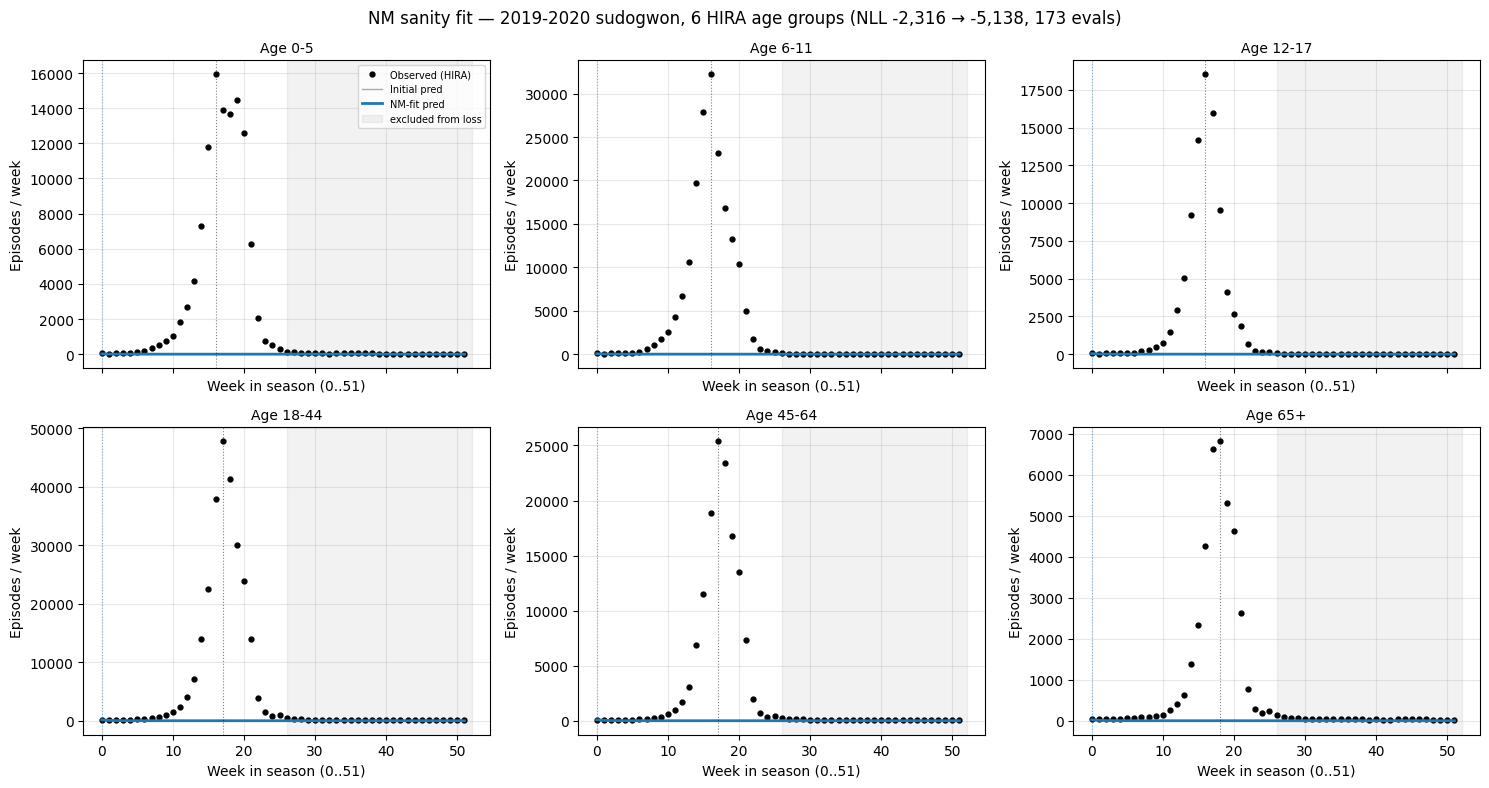

In [5]:
# Cell 5 — Final prediction + 6-panel fit plot
pred_final, sim_final, daily_inc_final = predict_from_vec(sol.x)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, ag in zip(axes.flat, HIRA_AGE_GROUPS):
    obs = target_by_age["hira_counts"][ag]
    pi = pred_init[ag]
    pf = pred_final[ag]
    weeks_obs = target_by_age["week_in_season"]
    # observed (points)
    ax.plot(weeks_obs, obs, "o", color="black", markersize=3.5,
            label="Observed (HIRA)")
    # initial prediction (gray)
    ax.plot(np.arange(len(pi)), pi, color="#888888", lw=1.0, alpha=0.7,
            label="Initial pred")
    # final prediction (color)
    ax.plot(np.arange(len(pf)), pf, color="#1f77b4", lw=2.0,
            label="NM-fit pred")
    # first-peak boundary
    ax.axvspan(FIRST_PEAK_END_WEEK, len(pf), alpha=0.10, color="gray",
               label="excluded from loss")
    # peak markers
    if obs.max() > 0:
        peak_obs = int(np.argmax(obs))
        ax.axvline(peak_obs, color="black", linestyle=":", lw=0.8, alpha=0.5)
    if pf.max() > 0:
        peak_pred = int(np.argmax(pf))
        ax.axvline(peak_pred, color="#1f77b4", linestyle=":", lw=0.8, alpha=0.5)
    ax.set_title(f"Age {ag}", fontsize=10)
    ax.set_xlabel("Week in season (0..51)")
    ax.set_ylabel("Episodes / week")
    ax.grid(alpha=0.3)
    if ax is axes.flat[0]:
        ax.legend(fontsize=7, loc="upper right")
fig.suptitle(f"NM sanity fit — {SEASON} sudogwon, 6 HIRA age groups "
             f"(NLL {nll_history[0]:,.0f} → {sol.fun:,.0f}, {sol.nfev} evals)",
             fontsize=12)
fig.tight_layout()
fig.savefig(FIT_PNG, dpi=150, bbox_inches="tight")
print(f"saved {FIT_PNG}")
plt.show()


In [6]:
# Cell 6 — Bound-hit + residual + age-bias diagnostics
final_vec = sol.x
bounds_arr = np.array(bounds)
lo, hi = bounds_arr[:, 0], bounds_arr[:, 1]
span = hi - lo
dist_lo = (final_vec - lo) / span     # fraction of range from lower bound
dist_hi = (hi - final_vec) / span
TOL = 0.02  # 2% of bound range

print("Parameters near a bound (within 2% of range):")
hit_lo, hit_hi = [], []
for i, n in enumerate(names):
    if dist_lo[i] < TOL:
        hit_lo.append((n, final_vec[i], lo[i]))
    if dist_hi[i] < TOL:
        hit_hi.append((n, final_vec[i], hi[i]))
if not hit_lo and not hit_hi:
    print("  (none)")
for n, v, b in hit_lo:
    print(f"  LOWER  {n:>22}: {v:.4f}  (bound {b:.4f})")
for n, v, b in hit_hi:
    print(f"  UPPER  {n:>22}: {v:.4f}  (bound {b:.4f})")

print(f"\nGamma report fitted: {final_vec[18]:.4f}  "
      f"(bound: {lo[18]:.2f} .. {hi[18]:.2f}, current HIRA-B suggestion 0.05..0.5)")

# Phi means by age block
phi_vec = np.ones(15)
idx = 4
for a in range(15):
    if a == 5:
        continue
    phi_vec[a] = final_vec[idx]; idx += 1
phi_children = phi_vec[:4].mean()  # 0-19
phi_adult = phi_vec[4:13].mean()   # 20-64
phi_elderly = phi_vec[13:].mean()  # 65+
print(f"\nPhi by age block:")
print(f"  children (0-19):  mean={phi_children:.3f}  values={np.round(phi_vec[:4], 3).tolist()}")
print(f"  adult (20-64):    mean={phi_adult:.3f}")
print(f"  elderly (65+):    mean={phi_elderly:.3f}  values={np.round(phi_vec[13:], 3).tolist()}")

# min_rate floor hits (HIRA-D)
MIN_RATE = 1.0
n_floor_hits = 0
n_total_weeks = 0
for ag in HIRA_AGE_GROUPS:
    p = pred_final[ag]
    w = target_by_age["weights"][ag]
    mask = w > 0
    n_floor_hits += int(np.sum(p[mask] < MIN_RATE))
    n_total_weeks += int(mask.sum())
floor_frac = n_floor_hits / max(1, n_total_weeks)
print(f"\nPoisson min_rate floor (={MIN_RATE}) hit: "
      f"{n_floor_hits}/{n_total_weeks} weeks = {floor_frac*100:.1f}%")

# Peak alignment per age
print(f"\nPeak alignment (observed vs predicted week):")
peak_align = []
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    if obs.max() == 0 or pf.max() == 0:
        continue
    pw_obs = int(np.argmax(obs))
    pw_pred = int(np.argmax(pf))
    delta = pw_pred - pw_obs
    peak_align.append((ag, pw_obs, pw_pred, delta))
    print(f"  {ag:>6}: obs W{pw_obs:>2}  pred W{pw_pred:>2}  Δ={delta:+d}")

# Age-bias signal: ratio of (pred_peak / obs_peak) per group
print(f"\nAge-bias signal (pred_peak / obs_peak, == 1.0 means perfect):")
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    if obs.max() == 0:
        continue
    ratio = pf.max() / obs.max()
    flag = "↑↑ overshoot" if ratio > 1.5 else ("↓↓ undershoot" if ratio < 0.66 else "ok")
    print(f"  {ag:>6}: peak ratio = {ratio:>5.2f}  {flag}")

# Residual sum (predicted - observed) per age, weighted weeks only
print(f"\nResidual sum (Σ(pred-obs) on weighted weeks):")
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    w = target_by_age["weights"][ag]
    n_weeks_min = min(len(obs), len(pf))
    diff = pf[:n_weeks_min] - obs[:n_weeks_min]
    weighted = diff * w[:n_weeks_min]
    print(f"  {ag:>6}: Σresid = {weighted.sum():>+12,.0f}  "
          f"(obs sum {obs[:n_weeks_min].sum():>10,.0f})")


Parameters near a bound (within 2% of range):
  LOWER                  beta_h: 0.0504  (bound 0.0010)
  LOWER                  beta_w: 0.0498  (bound 0.0010)
  LOWER                  beta_s: 0.0512  (bound 0.0010)
  LOWER                  beta_o: 0.0513  (bound 0.0010)

Gamma report fitted: 0.5138  (bound: 0.01 .. 1.00, current HIRA-B suggestion 0.05..0.5)

Phi by age block:
  children (0-19):  mean=0.991  values=[0.953, 1.009, 1.002, 1.0]
  adult (20-64):    mean=0.999
  elderly (65+):    mean=1.012  values=[1.006, 1.018]

Poisson min_rate floor (=1.0) hit: 124/156 weeks = 79.5%

Peak alignment (observed vs predicted week):
     0-5: obs W16  pred W 0  Δ=-16
    6-11: obs W16  pred W 0  Δ=-16
   12-17: obs W16  pred W 0  Δ=-16
   18-44: obs W17  pred W 0  Δ=-17
   45-64: obs W17  pred W 0  Δ=-17
     65+: obs W18  pred W 0  Δ=-18

Age-bias signal (pred_peak / obs_peak, == 1.0 means perfect):
     0-5: peak ratio =  0.00  ↓↓ undershoot
    6-11: peak ratio =  0.00  ↓↓ undershoot
   12-

saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_diagnostics.png


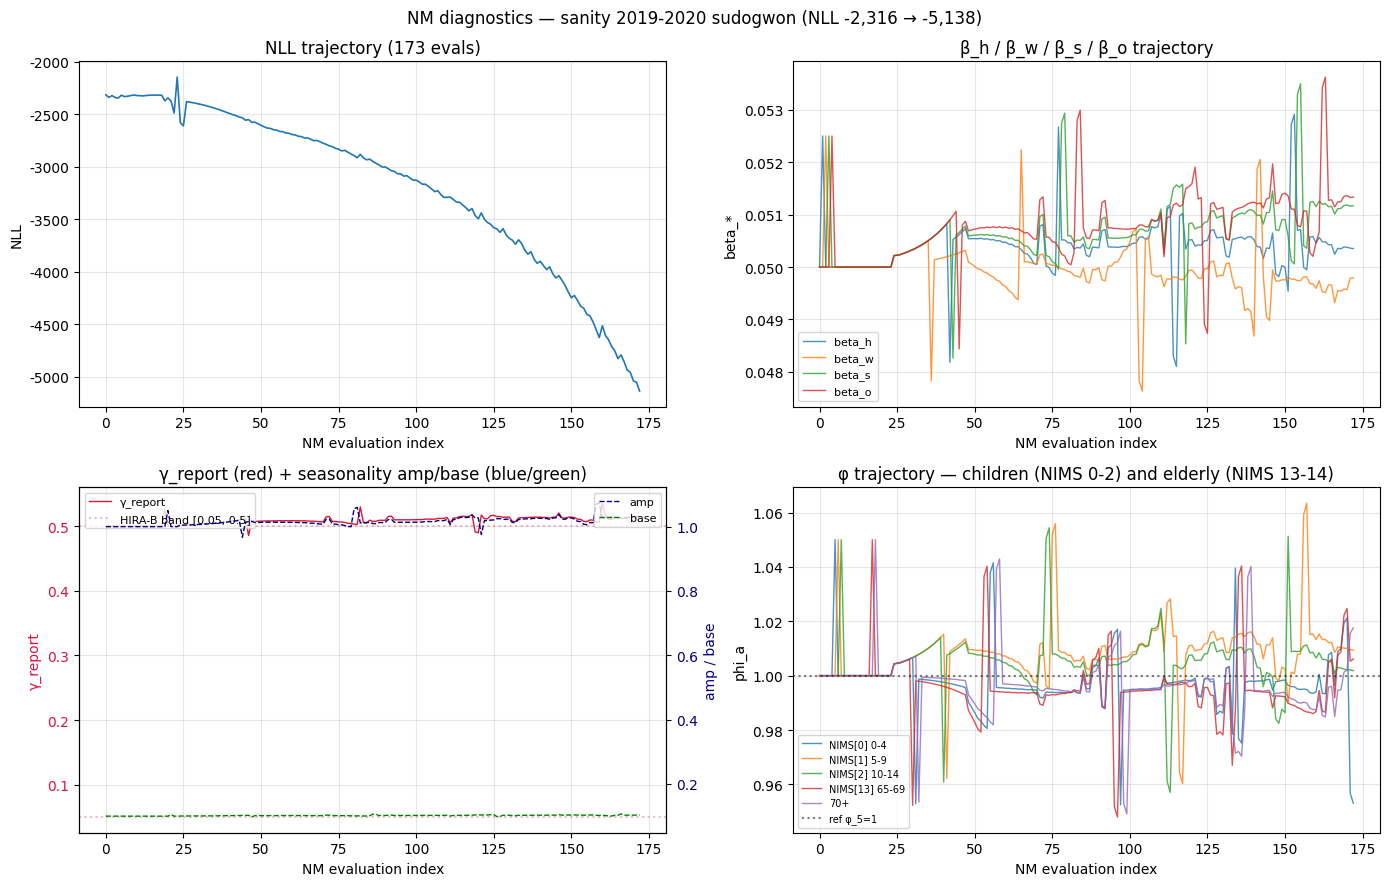

In [7]:
# Cell 7 — Diagnostics plot: NLL trajectory + key-parameter trajectory
nll_arr = np.asarray(nll_history)
vec_arr = np.asarray(vec_history)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (0,0) NLL trajectory (semilog if very large)
ax = axes[0, 0]
ax.plot(nll_arr, lw=1.2, color="#1f77b4")
ax.set_xlabel("NM evaluation index")
ax.set_ylabel("NLL")
ax.set_title(f"NLL trajectory ({len(nll_arr)} evals)")
ax.grid(alpha=0.3)
if nll_arr.max() / max(nll_arr.min(), 1e-9) > 50:
    ax.set_yscale("log")

# (0,1) beta trajectories
ax = axes[0, 1]
beta_labels = ["beta_h", "beta_w", "beta_s", "beta_o"]
for i, label in enumerate(beta_labels):
    ax.plot(vec_arr[:, i], lw=1.0, label=label, alpha=0.8)
ax.set_xlabel("NM evaluation index")
ax.set_ylabel("beta_*")
ax.set_title("β_h / β_w / β_s / β_o trajectory")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (1,0) gamma_report + seasonality trajectories
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(vec_arr[:, 18], lw=1.0, color="crimson", label="γ_report")
ax.set_ylabel("γ_report", color="crimson")
ax.axhline(0.05, color="crimson", linestyle=":", alpha=0.3)
ax.axhline(0.5, color="crimson", linestyle=":", alpha=0.3,
           label="HIRA-B band [0.05, 0.5]")
ax.tick_params(axis="y", labelcolor="crimson")
ax2.plot(vec_arr[:, 19], lw=1.0, color="navy", label="amp", linestyle="--")
ax2.plot(vec_arr[:, 20], lw=1.0, color="green", label="base", linestyle="--")
ax2.set_ylabel("amp / base", color="navy")
ax2.tick_params(axis="y", labelcolor="navy")
ax.set_xlabel("NM evaluation index")
ax.set_title("γ_report (red) + seasonality amp/base (blue/green)")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# (1,1) phi (selected: children + elderly)
ax = axes[1, 1]
phi_idx_by_age = {}
idx = 4
for a in range(15):
    if a == 5:
        continue
    phi_idx_by_age[a] = idx; idx += 1
for a in [0, 1, 2, 13, 14]:
    label = "70+" if a == 14 else f"NIMS[{a}] {a*5}-{a*5+4}"
    ax.plot(vec_arr[:, phi_idx_by_age[a]], lw=1.0, label=label, alpha=0.8)
ax.axhline(1.0, color="black", linestyle=":", alpha=0.5, label="ref φ_5=1")
ax.set_xlabel("NM evaluation index")
ax.set_ylabel("phi_a")
ax.set_title("φ trajectory — children (NIMS 0-2) and elderly (NIMS 13-14)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle(
    f"NM diagnostics — sanity {SEASON} sudogwon "
    f"(NLL {nll_arr[0]:,.0f} → {nll_arr[-1]:,.0f})", fontsize=12,
)
fig.tight_layout()
fig.savefig(DIAG_PNG, dpi=150, bbox_inches="tight")
print(f"saved {DIAG_PNG}")
plt.show()


In [8]:
# Cell 8 — Save JSON result
import json

result_dict = {
    "season": SEASON,
    "tag": "sanity_nm",
    "method": "Nelder-Mead",
    "max_iter": MAX_ITER,
    "n_evaluations": int(sol.nfev),
    "success": bool(sol.success),
    "message": str(sol.message),
    "elapsed_seconds": float(elapsed),
    "nll_initial": float(nll_history[0]),
    "nll_final": float(sol.fun),
    "nll_improvement": float(nll_history[0] - sol.fun),
    "vector": [float(v) for v in sol.x],
    "param_names": names,
    "bounds": [(float(a), float(b)) for a, b in bounds],
    "bound_hits_lower": [n for n, _, _ in hit_lo],
    "bound_hits_upper": [n for n, _, _ in hit_hi],
    "gamma_report_assumed": GAMMA_ASSUMED,
    "seed_e_factor": SEED_E_FACTOR,
    "initial_immunity": INITIAL_IMMUNITY,
    "first_peak_end_week": FIRST_PEAK_END_WEEK,
    "seed_by_age": [float(x) for x in seed_by_age],
    "seed_total": float(seed_by_age.sum()),
    "min_rate_floor": MIN_RATE,
    "min_rate_floor_hits": int(n_floor_hits),
    "min_rate_floor_total_weeks": int(n_total_weeks),
    "phi_block_means": {
        "children_0_19": float(phi_children),
        "adult_20_64": float(phi_adult),
        "elderly_65plus": float(phi_elderly),
    },
    "peak_alignment": [
        {"age": ag, "obs_week": int(pw_o), "pred_week": int(pw_p), "delta": int(d)}
        for (ag, pw_o, pw_p, d) in peak_align
    ],
    "age_bias_peak_ratio": {
        ag: (float(pred_final[ag].max() / target_by_age["hira_counts"][ag].max())
             if target_by_age["hira_counts"][ag].max() > 0 else None)
        for ag in HIRA_AGE_GROUPS
    },
}

with open(JSON_PATH, "w") as f:
    json.dump(result_dict, f, indent=2)
print(f"saved {JSON_PATH}")
print(f"\n=== Summary ===")
print(f"NLL: {result_dict['nll_initial']:,.2f} → {result_dict['nll_final']:,.2f}")
print(f"Wall time: {result_dict['elapsed_seconds']:.1f}s, {sol.nfev} evals")
print(f"Bound hits: lower={result_dict['bound_hits_lower']}, "
      f"upper={result_dict['bound_hits_upper']}")


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA.json

=== Summary ===
NLL: -2,316.34 → -5,137.74
Wall time: 114.3s, 173 evals
Bound hits: lower=['beta_h', 'beta_w', 'beta_s', 'beta_o'], upper=[]


## Interpretation

This notebook is generated by `scripts/build_sanity_nm_notebook.py` and
written as-executed. Re-run the build script to refresh, or read the JSON
at `outputs/calibration/sanity_nm_2019-2020_HIRA.json` for machine-readable
results.

The textual report (the answer to the user's NM sanity check) is in the
console — see Cell 8 output and the diagnostics in Cell 6.
